In [34]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import joblib
import random
import pickle
import numpy as np
import pandas as pd
import tempfile
import argparse
from datetime import datetime

from sklearn.metrics import roc_auc_score, f1_score, average_precision_score
from sklearn.metrics import roc_curve, precision_recall_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

import ray
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
import shap
import matplotlib.pyplot as plt

import config
from preprocessing_utils import ClinicalPreprocessorWrapper, MrnaPreprocessorWrapper, MutationPreprocessorWrapper
from model_utils import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [29]:
print("Loading data...")

X_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
y_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))
y_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_val.joblib"))
X_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_val.joblib"))
X_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_test.joblib"))
y_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_test.joblib"))

clinical_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "clinical_cols.joblib"))
mrna_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mrna_cols.joblib"))
mutation_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mutation_cols.joblib"))

# Load best hyperparameters
with open('XGBoost_raytune_best_hyperparams.pkl', 'rb') as f:
    best_config = pickle.load(f)

print(f"Loaded hyperparameters: {best_config}")

# Split by modality
clinical_train = X_train[clinical_cols]
mrna_train = X_train[mrna_cols]
mutation_train = X_train[mutation_cols]

clinical_val= X_val[clinical_cols]
mrna_val = X_val[mrna_cols]
mutation_val = X_val[mutation_cols]

clinical_test = X_test[clinical_cols]
mrna_test = X_test[mrna_cols]
mutation_test = X_test[mutation_cols]

clinical_prep = ClinicalPreprocessorWrapper(
    cols_to_remove=config.CLINICAL_COLS_TO_REMOVE,
    categorical_cols=config.CATEGORICAL_COLS,
    max_null_frac=config.CLINICAL_MAX_NULL_FRAC,
    uniform_thresh=config.CLINICAL_UNIFORM_THRESH,
)
mrna_prep = MrnaPreprocessorWrapper(
    max_null_frac=config.MAX_NULL_FRAC,
    uniform_thresh=config.UNIFORM_THRESHOLD,
    random_state=config.SEED,
)
mutation_prep = MutationPreprocessorWrapper(
    max_mutation_count=best_config["max_mutation_count"],
    uniform_thresh=best_config["mutation_uniform_thresh"],
)

# Fit preprocessors on training data
clinical_prep.fit(clinical_train)
mrna_prep.fit(mrna_train, y_train)
mutation_prep.fit(mutation_train)

# Transform training and validation data
clinical_train = clinical_prep.transform(clinical_train)
clinical_val = clinical_prep.transform(clinical_val)
clinical_test = clinical_prep.transform(clinical_test)

mrna_train = mrna_prep.transform(mrna_train)
mrna_val = mrna_prep.transform(mrna_val)
mrna_test = mrna_prep.transform(mrna_test)

mutation_train = mutation_prep.transform(mutation_train)
mutation_val = mutation_prep.transform(mutation_val)
mutation_test = mutation_prep.transform(mutation_test)

# Create data loaders
train_loader = to_loader(clinical_train, mrna_train, mutation_train, y_train, shuffle=True)
val_loader = to_loader(clinical_val, mrna_val, mutation_val, y_val)
test_loader = to_loader(clinical_test, mrna_test, mutation_test, y_test)

Loading data...
Loaded hyperparameters: {'fs_method': 'XGBoost', 'clin_hidden': [128, 64], 'mrna_hidden': [64], 'mut_hidden': [128, 64], 'clin_dropout': [0.2, 0.2], 'mrna_dropout': [0.2, 0.2], 'mut_dropout': [0.2, 0.2], 'fusion_hidden': 64, 'fusion_dropout': 0.007983126110107097, 'lr': 4.9281222976954986e-05, 'activation': 'silu', 'max_mutation_count': 15, 'mutation_uniform_thresh': 0.9614937166942913, 'optimizer': 'RMSprop', 'weight_decay': 9.565499215943819e-05, 'momentum': 0.8065338190118916, 'nesterov': False, 'rmsprop_alpha': 0.9387150001497508, 'fs_learning_rate': 0.018585951462501547, 'fs_max_depth': 9, 'fs_n_estimators': 100, 'fs_threshold': 'median', 'fs_max_features': 100}


In [30]:
print(f"Training final model with best hyperparameters:\n{best_config}\n")

# Create final model
final_model = MultimodalNet(
    clin_dim=clinical_train.shape[1],
    mrna_dim=mrna_train.shape[1],
    mut_dim=mutation_train.shape[1],
    clin_hidden=best_config["clin_hidden"],
    mrna_hidden=best_config["mrna_hidden"],
    mut_hidden=best_config["mut_hidden"],
    clin_dropout=best_config["clin_dropout"],
    mrna_dropout=best_config["mrna_dropout"],
    mut_dropout=best_config["mut_dropout"],
    activation=best_config.get("activation", "relu"),
    fusion_hidden=best_config["fusion_hidden"],
    fusion_dropout=best_config["fusion_dropout"],
    use_gene_sel=False  # No feature selection
).to(device)

optimizer = build_optimizer(final_model, best_config)
pos_weight_value = torch.tensor(
    (len(y_train) - y_train.sum()) / y_train.sum(), 
    dtype=torch.float32
).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

# Train the final model
best_state = train_one_fold(train_loader, val_loader, final_model, optimizer, criterion, config.SEED, device)
final_model.load_state_dict(best_state)

# Find optimal threshold on validation set
final_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for clin, mrna, mut, y in val_loader:
        clin, mrna, mut, y = clin.to(device), mrna.to(device), mut.to(device), y.to(device)
        probs = torch.sigmoid(final_model(clin, mrna, mut)).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
print("AUROC with best weights (sanity check):", roc_auc_score(all_labels, all_probs))

thresholds = np.linspace(0.001, 0.9, 200)
best_threshold, best_f1_val = 0.5, 0
for t in thresholds:
    preds = (all_probs >= t).astype(float)
    f1 = f1_score(all_labels, preds, zero_division=0)
    if f1 > best_f1_val:
        best_f1_val = f1
        best_threshold = t

print(f"Optimal threshold for validation: {best_threshold:.4f}")

# Evaluate on validation set
val_metrics = evaluate_with_threshold(final_model, val_loader, 0.5, device)
print(f"\nValidation metrics:")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}")

# Save the final model
torch.save(final_model.state_dict(), 'final_model_raytune.pt')
print("\nFinal model saved to 'final_model_raytune.pt'")

Training final model with best hyperparameters:
{'fs_method': 'XGBoost', 'clin_hidden': [128, 64], 'mrna_hidden': [64], 'mut_hidden': [128, 64], 'clin_dropout': [0.2, 0.2], 'mrna_dropout': [0.2, 0.2], 'mut_dropout': [0.2, 0.2], 'fusion_hidden': 64, 'fusion_dropout': 0.007983126110107097, 'lr': 4.9281222976954986e-05, 'activation': 'silu', 'max_mutation_count': 15, 'mutation_uniform_thresh': 0.9614937166942913, 'optimizer': 'RMSprop', 'weight_decay': 9.565499215943819e-05, 'momentum': 0.8065338190118916, 'nesterov': False, 'rmsprop_alpha': 0.9387150001497508, 'fs_learning_rate': 0.018585951462501547, 'fs_max_depth': 9, 'fs_n_estimators': 100, 'fs_threshold': 'median', 'fs_max_features': 100}

Epoch 001 | Train Loss: 0.8683 | Val AUROC: 0.8125 | P: 0.714 | R: 0.833 | F1: 0.769 | TN: 16 | FP: 4 | FN: 2 | TP: 10
Epoch 002 | Train Loss: 0.7573 | Val AUROC: 0.8125 | P: 0.714 | R: 0.833 | F1: 0.769 | TN: 16 | FP: 4 | FN: 2 | TP: 10
Epoch 003 | Train Loss: 0.6673 | Val AUROC: 0.8375 | P: 0.733


Test metrics:
  auroc: 0.7625
  auprc: 0.7200
  precision: 0.6667
  recall: 0.5000
  f1: 0.5714


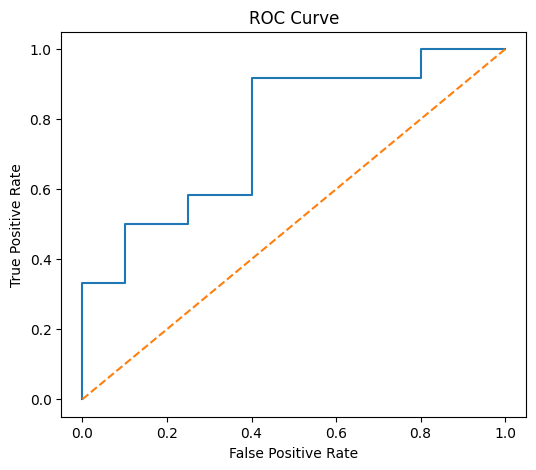

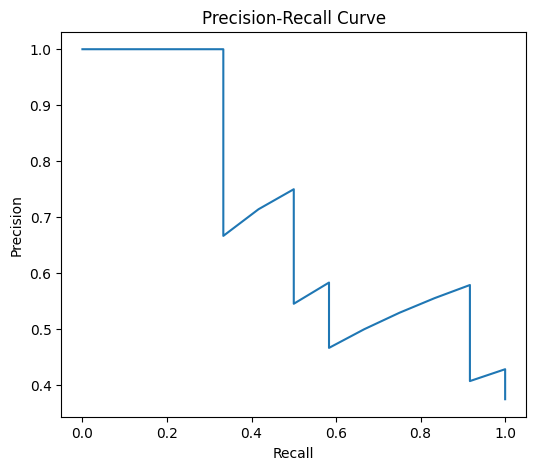

In [37]:
# evaluate on testing data
test_metrics = evaluate_with_threshold(final_model, test_loader, best_threshold, device)
print(f"\nTest metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")


final_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for clin, mrna, mut, y in test_loader:
        clin, mrna, mut, y = clin.to(device), mrna.to(device), mut.to(device), y.to(device)
        probs = torch.sigmoid(final_model(clin, mrna, mut)).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

# AUROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Precision–Recall curve
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [ ]:
# Prepare data (same as training)
print("\nPreparing data for SHAP analysis...")
# Convert to numpy arrays and ensure they are numeric
def to_numeric_array(data):
    """Convert data to numeric numpy array"""
    if isinstance(data, pd.DataFrame):
        return data.to_numpy(dtype=np.float32)
    elif isinstance(data, np.ndarray):
        return data.astype(np.float32)
    else:
        return np.array(data, dtype=np.float32)

clin_test_array = to_numeric_array(clinical_test)
mrna_test_array = to_numeric_array(mrna_test)
mut_test_array = to_numeric_array(mutation_test)

# Get actual feature names from preprocessed DataFrames
if isinstance(clinical_test, pd.DataFrame):
    clin_feature_names = list(clinical_test.columns)
else:
    clin_feature_names = [f"clinical_{i}" for i in range(clin_test_array.shape[1])]

if isinstance(mrna_test, pd.DataFrame):
    mrna_feature_names = list(mrna_test.columns)
else:
    mrna_feature_names = [f"mrna_{i}" for i in range(mrna_test_array.shape[1])]

if isinstance(mutation_test, pd.DataFrame):
    mut_feature_names = list(mutation_test.columns)
else:
    mut_feature_names = [f"mutation_{i}" for i in range(mut_test_array.shape[1])]

all_feature_names = clin_feature_names + mrna_feature_names + mut_feature_names

print(f"Number of features: Clinical={len(clin_feature_names)}, mRNA={len(mrna_feature_names)}, Mutation={len(mut_feature_names)}")
print(f"Sample clinical features: {clin_feature_names[:5]}")
print(f"Sample mRNA features: {mrna_feature_names[:5]}")
print(f"Sample mutation features: {mut_feature_names[:5]}")

# Concatenate features
X_test_combined = np.concatenate([clin_test_array, mrna_test_array, mut_test_array], axis=1).astype(np.float32)

print(f"\nCombined feature matrix shape: {X_test_combined.shape}")
print(f"Data type: {X_test_combined.dtype}")

# Store dimensions for splitting
clin_dim = clin_test_array.shape[1]
mrna_dim = mrna_test_array.shape[1]
mut_dim = mut_test_array.shape[1]

# Recreate the model with saved hyperparameters
print("\nRecreating model architecture...")
loaded_model = MultimodalNet(
    clin_dim=clin_dim,
    mrna_dim=mrna_dim,
    mut_dim=mut_dim,
    clin_hidden=best_config["clin_hidden"],
    mrna_hidden=best_config["mrna_hidden"],
    mut_hidden=best_config["mut_hidden"],
    clin_dropout=best_config["clin_dropout"],
    mrna_dropout=best_config["mrna_dropout"],
    mut_dropout=best_config["mut_dropout"],
    activation=best_config.get("activation", "relu"),
    fusion_hidden=best_config["fusion_hidden"],
    fusion_dropout=best_config["fusion_dropout"],
    use_gene_sel=False  # No feature selection
).to(device)

# Load saved weights
loaded_model.load_state_dict(torch.load('final_model_raytune.pt', map_location=device))
loaded_model.eval()

print("Model loaded successfully!")

# Create a wrapper function for the model that takes concatenated input
def model_predict(X):
    """Wrapper function for SHAP that splits concatenated features back into modalities"""
    loaded_model.eval()
    
    # Ensure X is float32 numpy array and 2D
    if not isinstance(X, np.ndarray):
        X = np.array(X, dtype=np.float32)
    else:
        X = X.astype(np.float32)
    
    # Ensure 2D shape
    if len(X.shape) == 1:
        X = X.reshape(1, -1)
    
    # Split features back into modalities
    clin = X[:, :clin_dim]
    mrna = X[:, clin_dim:clin_dim + mrna_dim]
    mut = X[:, clin_dim + mrna_dim:]
    
    # Convert to tensors
    clin_tensor = torch.tensor(clin, dtype=torch.float32).to(device)
    mrna_tensor = torch.tensor(mrna, dtype=torch.float32).to(device)
    mut_tensor = torch.tensor(mut, dtype=torch.float32).to(device)
    
    # Get predictions
    with torch.no_grad():
        outputs = loaded_model(clin_tensor, mrna_tensor, mut_tensor)
        probs = torch.sigmoid(outputs).cpu().numpy()
    
    # Ensure output is 1D for single sample or 2D column vector for multiple samples
    if probs.ndim == 0:
        probs = np.array([probs])
    elif probs.ndim == 1:
        pass  # Keep as is
    
    return probs

print("\nComputing SHAP values (this may take several minutes)...")
# Use DeepExplainer instead of KernelExplainer (faster for neural networks)
# First create a small background dataset
n_background = min(100, len(X_test_combined))
background = X_test_combined[:n_background]

# Create a PyTorch wrapper for the model
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, x):
        # Split concatenated input
        clin = x[:, :clin_dim]
        mrna = x[:, clin_dim:clin_dim + mrna_dim]
        mut = x[:, clin_dim + mrna_dim:]
        
        outputs = self.model(clin, mrna, mut)
        return torch.sigmoid(outputs).unsqueeze(1)

wrapped_model = ModelWrapper(loaded_model)
wrapped_model.eval()

# Use GradientExplainer (faster than KernelExplainer)
background_tensor = torch.tensor(background, dtype=torch.float32).to(device)
explainer = shap.GradientExplainer(wrapped_model, background_tensor)

# Compute SHAP values for test set (or subset if too large)
n_explain = min(500, len(X_test_combined))  # Reduced for speed
X_explain = torch.tensor(X_test_combined[:n_explain], dtype=torch.float32).to(device)
shap_values = explainer.shap_values(X_explain)

# Convert to numpy if needed
if isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.cpu().numpy()
elif isinstance(shap_values, list):
    shap_values = shap_values[0].cpu().numpy() if isinstance(shap_values[0], torch.Tensor) else shap_values[0]

# Remove extra dimension if present
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

print(f"SHAP values computed for {n_explain} samples")
print(f"SHAP values shape: {shap_values.shape}")

# Create beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_combined[:n_explain], 
                  feature_names=all_feature_names,
                  plot_type="dot",
                  max_display=60,
                  show=False)
plt.title("SHAP Beeswarm Plot - Final Ray Tune Model", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_beeswarm_raytune.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved to 'shap_beeswarm_raytune.png'")

In [26]:
import numpy as np

def permutation_importance_custom(model_predict, X, y, n_repeats=10, random_state=config.SEED):
    """
    Compute permutation importance for a custom model, similar to sklearn's version.
    model_predict: function that takes X and returns predicted probabilities.
    X: numpy array (n_samples, n_features)
    y: numpy array (n_samples,)
    """
    rng = np.random.RandomState(random_state)
    baseline_preds = model_predict(X).flatten()
    # binary cross-entropy (lower is better)
    baseline_loss = np.mean(-(y * np.log(baseline_preds + 1e-8) +
                             (1 - y) * np.log(1 - baseline_preds + 1e-8)))
    
    n_samples, n_features = X.shape
    importances = np.zeros((n_repeats, n_features))
    print("number of features", n_features)
    for col in range(n_features):
        if (col + 1) % 1000 == 0:
            print(f"we are on column {col + 1}")
        X_permuted = X.copy()
        for r in range(n_repeats):
            perm = rng.permutation(n_samples)
            X_permuted[:, col] = X[perm, col]

            perm_preds = model_predict(X_permuted).flatten()
            perm_loss = np.mean(-(y * np.log(perm_preds + 1e-8) +
                                  (1 - y) * np.log(1 - perm_preds + 1e-8)))
            importances[r, col] = perm_loss - baseline_loss  # bigger = more important
    
    return importances.mean(axis=0), importances.std(axis=0)

# ---- RUN PERMUTATION IMPORTANCE ----

print("\nRunning permutation feature importance...")

# Use same X test subset as SHAP
X_for_importance = X_test_combined[:n_explain]
y_for_importance = y_test[:n_explain]   # <-- make sure y_test is loaded earlier

mean_imp, std_imp = permutation_importance_custom(
    model_predict,
    X_for_importance,
    y_for_importance,
    n_repeats=10,
    random_state=config.SEED
)

# Sort by importance
sorted_idx = np.argsort(mean_imp)[::-1]

print("\nTop 30 most important features (Permutation Importance):\n")
for idx in sorted_idx[:30]:
    print(f"{all_feature_names[idx]:35s}  importance={mean_imp[idx]:.5f} ± {std_imp[idx]:.5f}")


Running permutation feature importance...
number of features 30048
we are on column 1000
we are on column 2000
we are on column 3000
we are on column 4000
we are on column 5000
we are on column 6000
we are on column 7000
we are on column 8000
we are on column 9000
we are on column 10000


KeyboardInterrupt: 

In [ ]:
print(all_feature_names)


In [ ]:
# Convert lists of column names into proper masks
clin_mask = np.zeros(len(mean_imp), dtype=bool)
clin_mask[:len(clinical_cols)] = True

mrna_mask = np.zeros(len(mean_imp), dtype=bool)
mrna_mask[len(clinical_cols):len(clinical_cols)+len(mrna_cols)] = True

mut_mask = np.zeros(len(mean_imp), dtype=bool)
mut_mask[len(clinical_cols)+len(mrna_cols):] = True

# Compute mean importance per modality
clin_mean = mean_imp[clin_mask].mean()
mrna_mean = mean_imp[mrna_mask].mean()
mut_mean  = mean_imp[mut_mask].mean()

print("\n=== Mean Permutation Importance by Modality ===")
print(f"Clinical:  {clin_mean:.6f}")
print(f"mRNA:      {mrna_mean:.6f}")
print(f"Mutation:  {mut_mean:.6f}")


In [ ]:
import numpy as np

# Take absolute values first
abs_imp = np.abs(mean_imp)

clin_mask = np.zeros(len(mean_imp), dtype=bool)
clin_mask[:len(clinical_cols)] = True

mrna_mask = np.zeros(len(mean_imp), dtype=bool)
mrna_mask[len(clinical_cols):len(clinical_cols)+len(mrna_cols)] = True

mut_mask = np.zeros(len(mean_imp), dtype=bool)
mut_mask[len(clinical_cols)+len(mrna_cols):] = True


clinical_mean = abs_imp[clin_mask].mean()
mrna_mean = abs_imp[mrna_mask].mean()
mutation_mean = abs_imp[mut_mask].mean()

print("=== Mean Permutation Importance by Modality (abs) ===")
print(f"Clinical:  {clinical_mean:.6f}")
print(f"mRNA:      {mrna_mean:.6f}")
print(f"Mutation:  {mutation_mean:.6f}")



In [ ]:
import pandas as pd

# Convert to Series if needed
if not isinstance(mean_imp, pd.Series):
    mean_imp = pd.Series(mean_imp)

def print_top_features(modality_name, cols):
    # Filter to this modality
    imp = mean_imp[cols]
    
    # Top 10 positive
    top_pos = imp.sort_values(ascending=False).head(10)
    
    # Top 10 negative
    top_neg = imp.sort_values().head(10)   # smallest = most negative
    
    print(f"\n===== {modality_name}: Top 10 Positive Features =====")
    for feat, val in top_pos.items():
        print(f"{feat:40s} {val:.6f}")

    print(f"\n===== {modality_name}: Top 10 Negative Features =====")
    for feat, val in top_neg.items():
        print(f"{feat:40s} {val:.6f}")

# Run for each modality
print_top_features("Clinical", clinical_cols)
print_top_features("mRNA", mrna_cols)
print_top_features("Mutation", mutation_cols)


In [28]:
clin_mask = np.isin(all_feature_names, clinical_cols)
mrna_mask = np.isin(all_feature_names, mrna_cols)
mut_mask = np.isin(all_feature_names, mutation_cols)

clin_means = mean_imp[clin_mask]
mrna_means = mean_imp[mrna_mask]
mut_means = mean_imp[mut_mask]

# Sort by importance
clin_sorted_idx = np.argsort(clin_means)[::-1]

print("\n clinical features (Permutation Importance):\n")
for idx in clin_sorted_idx:
    print(f"{all_feature_names[idx]:35s}  importance={mean_imp[idx]:.5f} ± {std_imp[idx]:.5f}")

# Sort by importance
mrna_sorted_idx = np.argsort(mrna_means)[::-1]

print("\nTop 30 most important mrna features (Permutation Importance):\n")
for idx in mrna_sorted_idx[:10]:
    print(f"{all_feature_names[idx]:35s}  importance={mean_imp[idx]:.5f} ± {std_imp[idx]:.5f}")
print()
for idx in mrna_sorted_idx[-10:]:
    print(f"{all_feature_names[idx]:35s}  importance={mean_imp[idx]:.5f} ± {std_imp[idx]:.5f}")



 clinical features (Permutation Importance):

MSI_SENSOR_SCORE                     importance=0.00008 ± 0.00091
MSI_SCORE_MANTIS                     importance=0.00000 ± 0.00002
TMB_NONSYNONYMOUS                    importance=-0.00002 ± 0.01485
ANEUPLOIDY_SCORE                     importance=-0.00077 ± 0.00057
AGE                                  importance=-0.00154 ± 0.00109
WEIGHT                               importance=-0.00212 ± 0.00180
TBL_SCORE                            importance=-0.01141 ± 0.00916

Top 30 most important mrna features (Permutation Importance):

FBXL22                               importance=-0.00024 ± 0.00010
ZNF664                               importance=0.00038 ± 0.00014
PIGV                                 importance=0.00038 ± 0.00016
ZNF623                               importance=-0.00026 ± 0.00025
PRDM15                               importance=-0.00020 ± 0.00019
NR2C2                                importance=-0.00035 ± 0.00021
CDC25B                

In [29]:
def print_top_for_modality(name, mask):
    means = mean_imp[mask]
    stds = std_imp[mask]

    # global indices of this modality's features
    global_idx = np.where(mask)[0]

    # sorted (descending) indices in the *global* feature list
    sorted_global_idx = global_idx[np.argsort(means)[::-1]]

    print(f"\n=== {name}: Top 10 positive features ===")
    for idx in sorted_global_idx[:10]:
        print(f"{all_feature_names[idx]:35s}  importance={mean_imp[idx]:.5f} ± {std_imp[idx]:.5f}")

    print(f"\n=== {name}: Top 10 negative features ===")
    for idx in sorted_global_idx[-10:]:
        print(f"{all_feature_names[idx]:35s}  importance={mean_imp[idx]:.5f} ± {std_imp[idx]:.5f}")


print_top_for_modality("Clinical", clin_mask)
print_top_for_modality("mRNA", mrna_mask)
print_top_for_modality("Mutation", mut_mask)



=== Clinical: Top 10 positive features ===
MSI_SENSOR_SCORE                     importance=0.00008 ± 0.00091
MSI_SCORE_MANTIS                     importance=0.00000 ± 0.00002
TMB_NONSYNONYMOUS                    importance=-0.00002 ± 0.01485
ANEUPLOIDY_SCORE                     importance=-0.00077 ± 0.00057
AGE                                  importance=-0.00154 ± 0.00109
WEIGHT                               importance=-0.00212 ± 0.00180
TBL_SCORE                            importance=-0.01141 ± 0.00916

=== Clinical: Top 10 negative features ===
MSI_SENSOR_SCORE                     importance=0.00008 ± 0.00091
MSI_SCORE_MANTIS                     importance=0.00000 ± 0.00002
TMB_NONSYNONYMOUS                    importance=-0.00002 ± 0.01485
ANEUPLOIDY_SCORE                     importance=-0.00077 ± 0.00057
AGE                                  importance=-0.00154 ± 0.00109
WEIGHT                               importance=-0.00212 ± 0.00180
TBL_SCORE                            importan